In [16]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager
from src.evaluation import Evaluator
from src.configmanagement.experimentconfigmanager import ExperimentRunner


disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1


config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',    
    )       
data_orchestrator = DataOrchestrator(config).build()


==                 persistence                  ==
forecasted ✓

==                 climateology                 ==
forecasted ✓

==                   nodegru                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.6217, val loss: 0.9617 ✓ (new best)
Epoch 11 train loss: 0.5448, val loss: 0.6801 ✓ (new best)
Epoch 21 train loss: 0.4950, val loss: 0.5666 ✓ (new best)
Epoch 31 train loss: 0.4629, val loss: 0.5009 ✓ (new best)
Epoch 41 train loss: 0.4435, val loss: 0.4824 (patience: 5/20)
lr has been updated from 1.00e-04 to 5.00e-05
Epoch 51 train loss: 0.3878, val loss: 0.4766 (patience: 1/20)
Epoch 61 train loss: 0.3670, val loss: 0.4513 ✓ (new best)
lr has been updated from 5.00e-05 to 2.50e-05
Epoch 71 train loss: 0.3423, val loss: 0.4980 (patience: 10/20)
lr has been updated from 2.50e-05 to 1.25e-05
Early stopping: Validation loss hasn't improved for 20 e

Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 230.29it/s]


Test loss: 0.7003
forecasted ✓

==                   nodelstm                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.6417, val loss: 0.9878 ✓ (new best)
Epoch 11 train loss: 0.5341, val loss: 0.6342 ✓ (new best)
Epoch 21 train loss: 0.4725, val loss: 0.6391 (patience: 5/20)
Epoch 31 train loss: 0.4433, val loss: 0.5676 (patience: 7/20)
lr has been updated from 1.00e-04 to 5.00e-05
Epoch 41 train loss: 0.4401, val loss: 0.5659 (patience: 4/20)
lr has been updated from 5.00e-05 to 2.50e-05
Epoch 51 train loss: 0.3703, val loss: 0.5390 (patience: 14/20)
lr has been updated from 2.50e-05 to 1.25e-05
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.5083
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 157.98it/s]


Test loss: 0.7553
forecasted ✓

==                  nodebilstm                  ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.6364, val loss: 0.8595 ✓ (new best)
Epoch 11 train loss: 0.5167, val loss: 0.4868 ✓ (new best)
Epoch 21 train loss: 0.4613, val loss: 0.5108 (patience: 5/20)
lr has been updated from 1.00e-04 to 5.00e-05
lr has been updated from 5.00e-05 to 2.50e-05
Epoch 31 train loss: 0.3774, val loss: 0.5122 (patience: 15/20)
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4764
trained ✓


Forecasting test: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 95.72it/s]


Test loss: 1.6460
forecasted ✓


computing metrics: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:27<00:00,  4.64s/it]


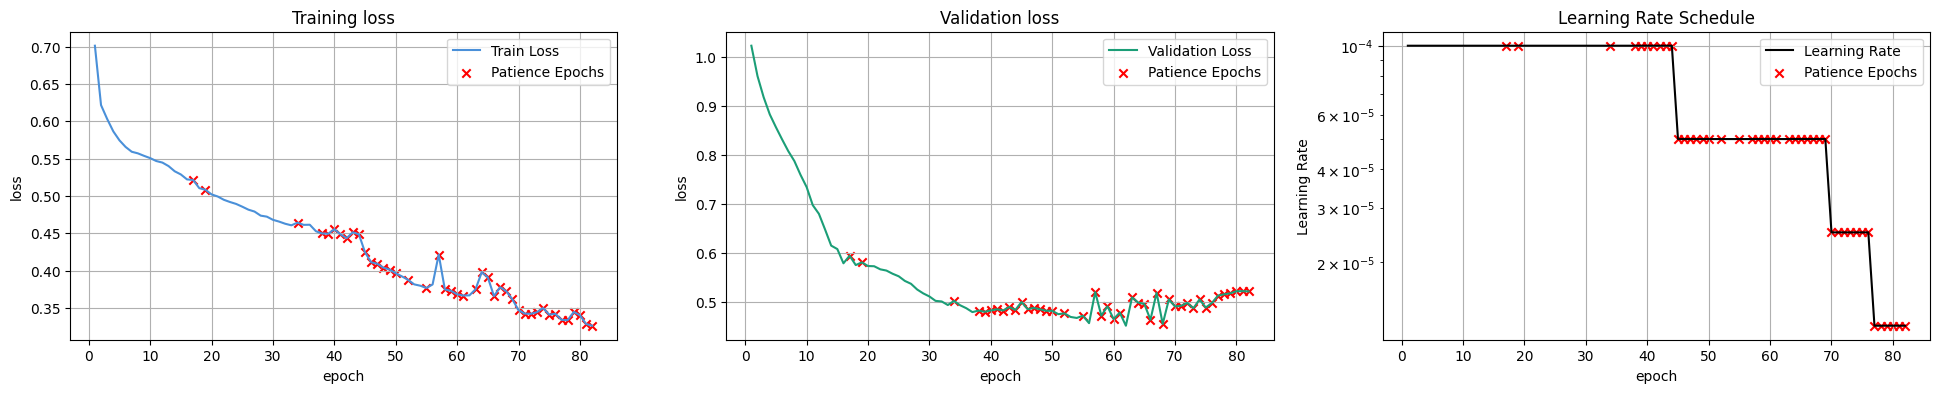

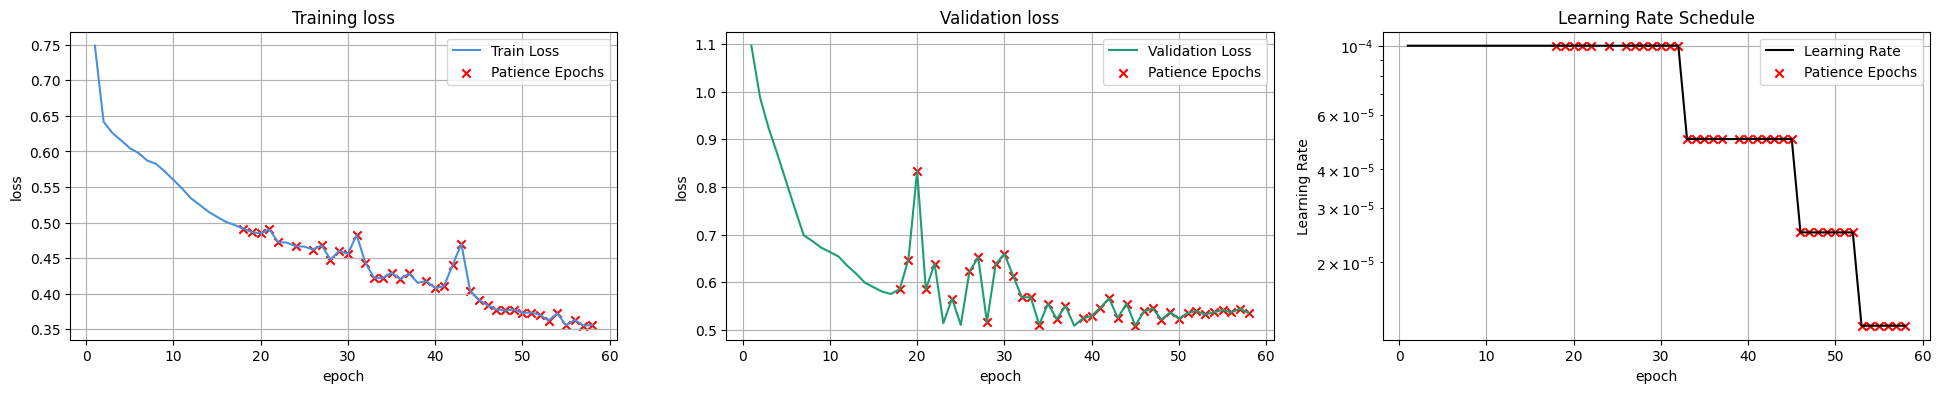

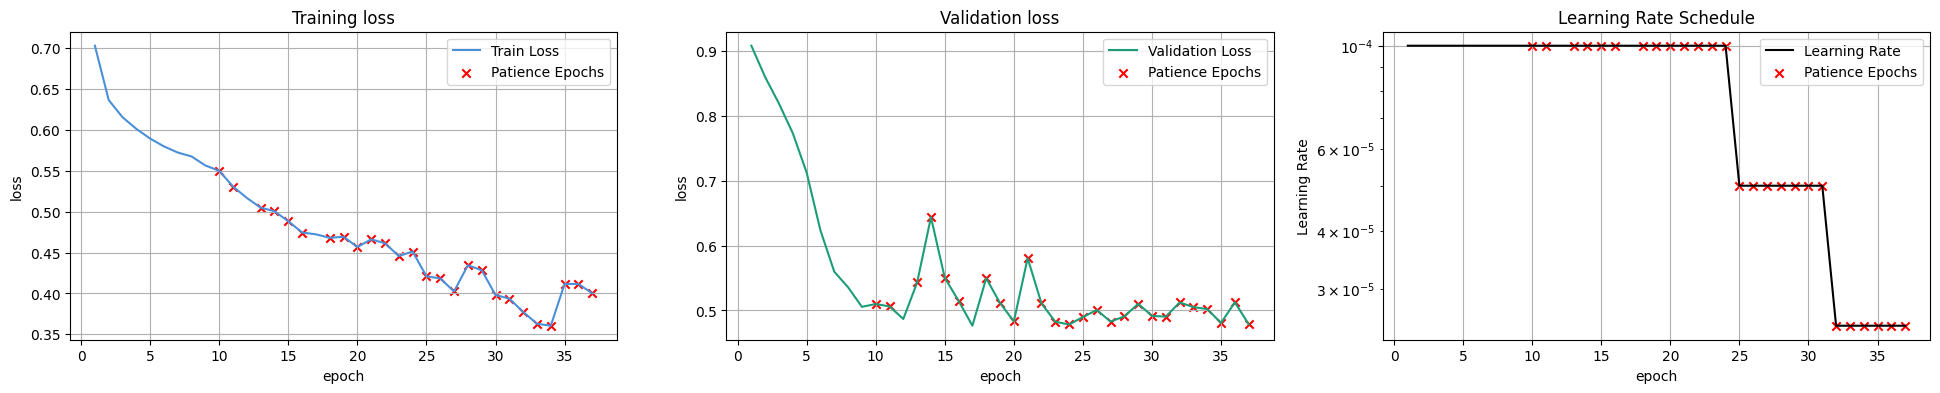

In [2]:

n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


# Usage:
runner = (ExperimentRunner(data_orchestrator, verbose = 2)
    .add_baseline_model('PersistenceModel', 'persistence')
    .add_baseline_model('ClimateologyModel', 'climateology')    
    .add_gnn('NodeGRUModel',    'nodegru',          'identity_graph',                       global_hparams=global_hparams)
    .add_gnn('NodeLSTMModel',   'nodelstm',         'identity_graph',                       global_hparams=global_hparams)        
    .add_gnn('NodeBiLSTMModel', 'nodebilstm',       'identity_graph',                       global_hparams=global_hparams)                        
)

results = runner.run()

In [ ]:
for nm, ml in runner.models_dictionary.items():
    ml.forecast('train')
    ml.forecast('val')    



forecasted ✓
forecasted ✓
forecasted ✓
forecasted ✓


Forecasting train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 633/633 [00:03<00:00, 172.75it/s]


Train loss: 0.3117
forecasted ✓


Forecasting val: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 52/52 [00:00<00:00, 175.05it/s]


Val loss: 0.5215
forecasted ✓


...

Val loss: 0.5351
forecasted ✓


Forecasting train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 633/633 [00:05<00:00, 114.87it/s]


Train loss: 0.3717
forecasted ✓


Forecasting val: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 52/52 [00:00<00:00, 93.84it/s]


Val loss: 0.4787
forecasted ✓


In [9]:
new_e = Evaluator(models = list(runner.models_dictionary.values()))
new_e.add_evaluation('0','trai')
new_e.add_evaluation('0','val')

UnboundLocalError: cannot access local variable 'prediction_collection' where it is not associated with a value

In [6]:
runner.evaluation.add_evaluation('0','train')
runner.evaluation.add_evaluation('0','val')
runner.evaluation.plotter.plot_metric('ccc', horizon = 'horizon_0', dataset = 'train')
runner.evaluation.plotter.plot_metric('ccc', horizon = 'horizon_0', dataset = 'val')
runner.evaluation.plotter.plot_metric('ccc', horizon = 'horizon_0', dataset = 'test')

KeyError: ('0', True)

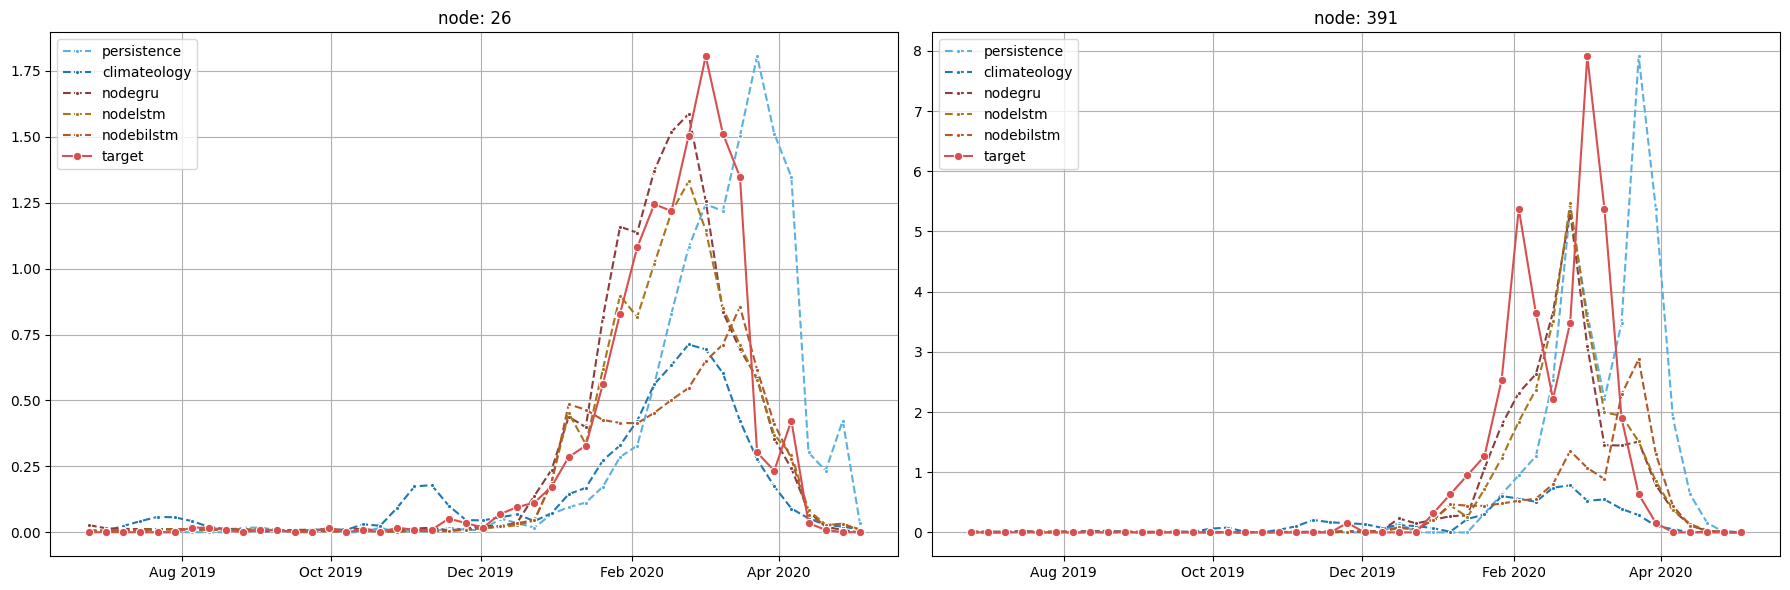

In [10]:
runner.evaluation.plotter.plot_timeseries([26,391])

(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'SK Hamburg [node: 15]'}, ylabel='target'>])

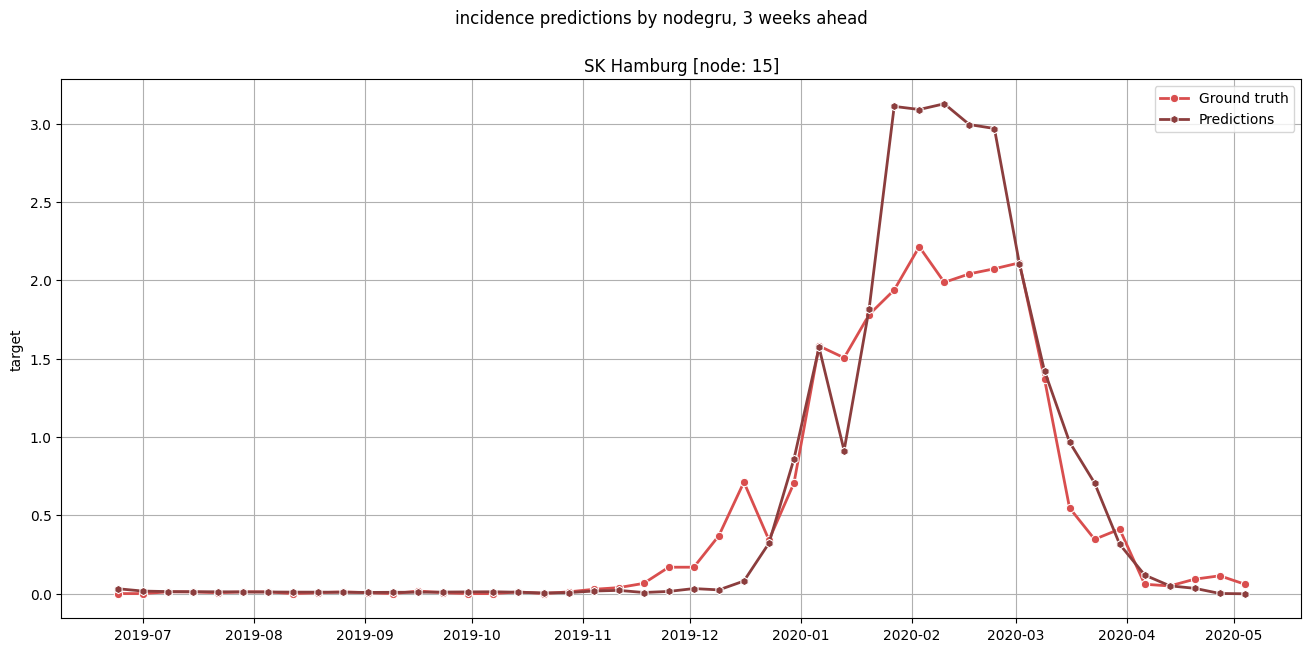

In [15]:
runner.models_dictionary['nodegru'].show_forecasts(15)
# runner.models_dictionary['nodelstm'].show_forecasts(26)